In [1]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
import train

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import mplhep as hep
hep.style.use("ATLAS")

In [2]:
ckpt_files = glob.glob(f"./hww_pcres_regressor/logs/version_0/checkpoints/*")
print(f"Found checkpoint files: {ckpt_files}")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Found checkpoint files: ['./hww_pcres_regressor/logs/version_0/checkpoints/reg-epoch=660-val_mae_loss=23.98.ckpt']
Using checkpoint: ./hww_pcres_regressor/logs/version_0/checkpoints/reg-epoch=660-val_mae_loss=23.98.ckpt


In [3]:
# Retrieve datamodule used in training
dm = train.main(train=False)
# Load model from checkpoint
model = LightningWBoson.load_from_checkpoint(ckpt_path)
model.eval() # used to inference -> not for training phase

# Set up the data module (prepare data and setup splits)
dm.setup(stage="test")  # Ensure test dataset is ready
# Get the test dataloader
test_loader = dm.test_dataloader()

# Run inference
train_features = np.zeros([0, dm.X.shape[1]])
predictions = np.zeros([0, dm.Y.shape[1]-2]) # without including W0 and W1 mass
true_labels = np.zeros([0, dm.Y.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():  # Disable gradient computation for inference
    for batch in test_loader:
        # Assuming batch contains inputs and targets
        inputs, targets = batch
        # print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Store predictions and true labels
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Evaluation mode, loading checkpoints...
Training objects shape: (376985, 72)
Target objects shape: (376985, 10)
Removed 0 rows with NaN or infinite values
Setting num_workers to 25
Loading model from checkpoint for evaluation... return datamodule
Creating test dataloader


In [4]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]

In [5]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = predictions[..., 3]
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = predictions[..., 7]
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = true_labels[..., 3]
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = true_labels[..., 7]
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

In [6]:
def rel_err_func(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    if (np.any(b == 0)):
        print("Warning: Zero values detected in denominator array.")
    mask = ~np.isnan(a) & ~np.isnan(b) & (b != 0)
    return (a[mask] - b[mask]) / b[mask]


In [7]:
def err_bounds(x, rel_err=0.2, offset=5.0):
    delta = rel_err * np.abs(x) + offset
    upper = x + delta
    lower = x - delta
    return upper, lower

In [8]:
def rmse(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    if (np.any(b == 0)):
        print("Warning: Zero values detected in denominator array.")
    mask = ~np.isnan(a) & ~np.isnan(b) & (b != 0)
    return np.sqrt(np.mean((a[mask] - b[mask]) ** 2))

In [9]:
def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 101), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 101), log=False, unit="GeV", color="black", vmax=1e3, offset=0.0, savepath=None):
    err = 0.2
    cor_mask = np.abs(rel_err_func(pred, truth)) <= err # set 20% relative error cut
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
        
    # Plot error guides aligned with bin edges
    upper, lower = err_bounds(bins_edges, rel_err=err, offset=offset)
    plt.plot(upper, bins_edges, color="gainsboro", linestyle="-", label=r"$\pm 20\% offset$")
    plt.plot(bins_edges, bins_edges, color="gainsboro", linestyle="--")
    plt.plot(lower, bins_edges, color="gainsboro", linestyle="-")
    
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}"+f" with RMSE: {rmse(pred, truth):.2f}", loc="right")
    print(f"Rel err < 20%: {100*np.sum(cor_mask)/len(truth):.2f} %")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

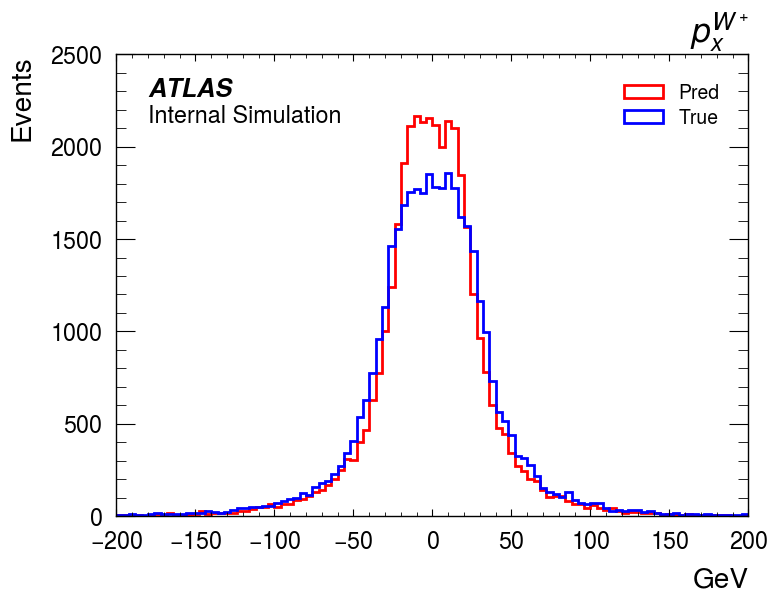

Rel err < 20%: 26.13 %


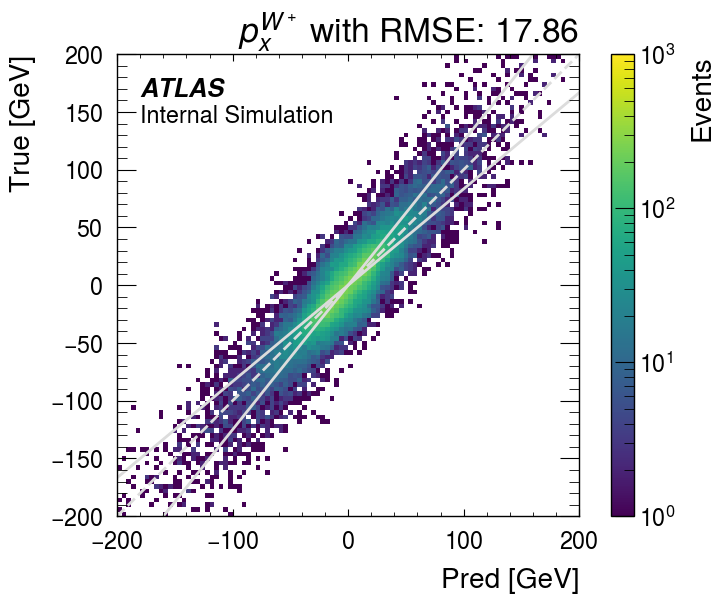

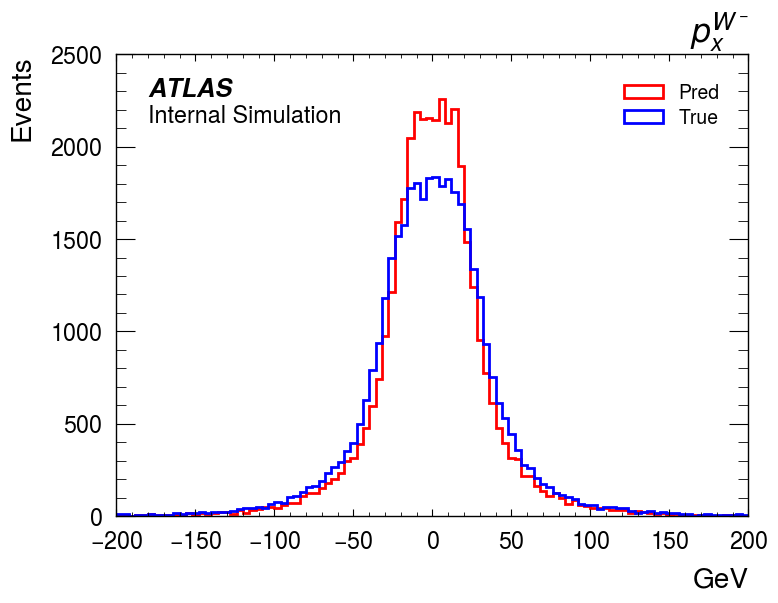

Rel err < 20%: 25.56 %


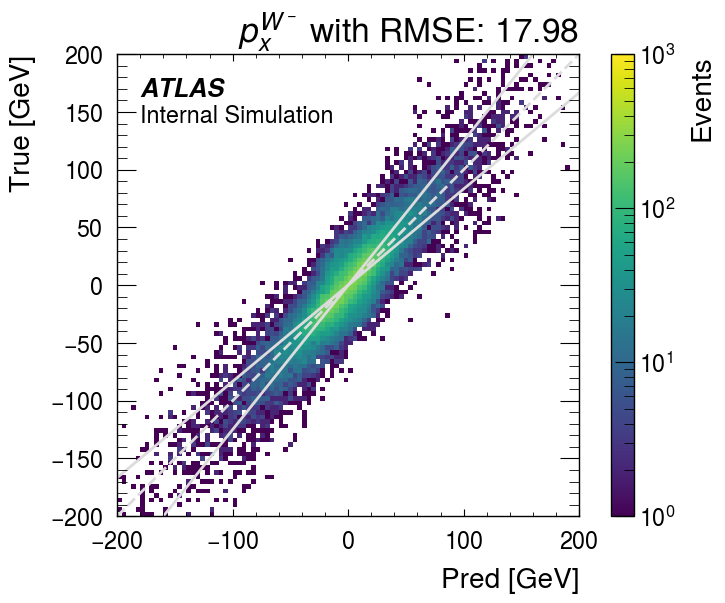

In [11]:
bins = np.linspace(-200, 200, 101)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True)

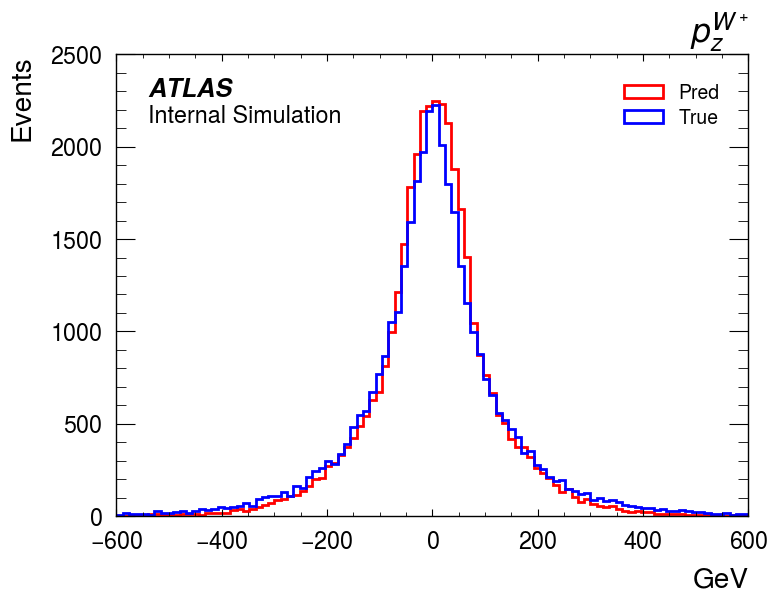

Rel err < 20%: 28.57 %


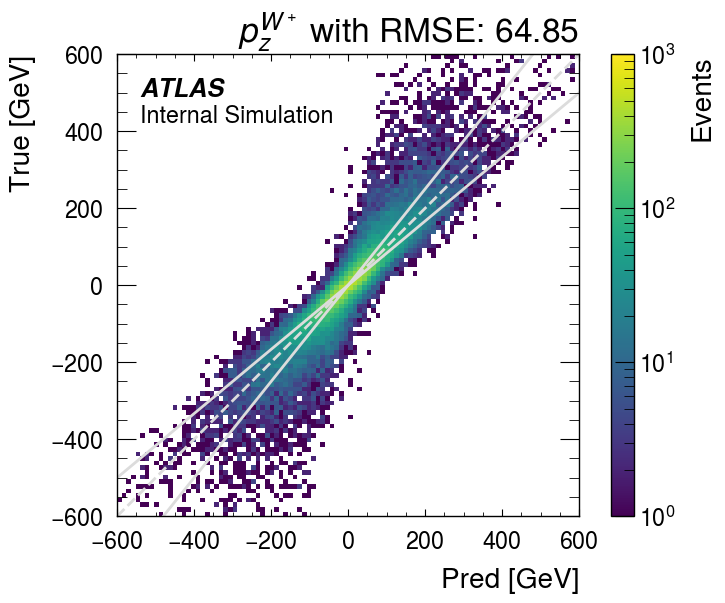

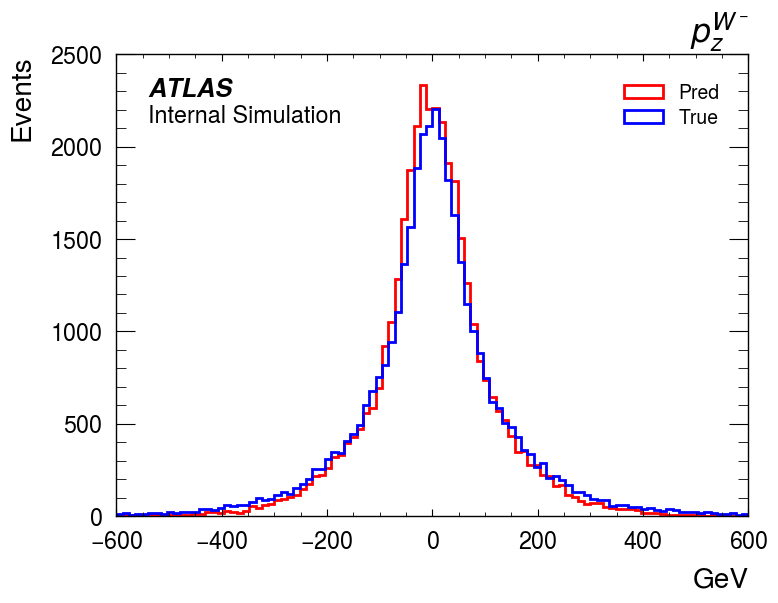

Rel err < 20%: 28.50 %


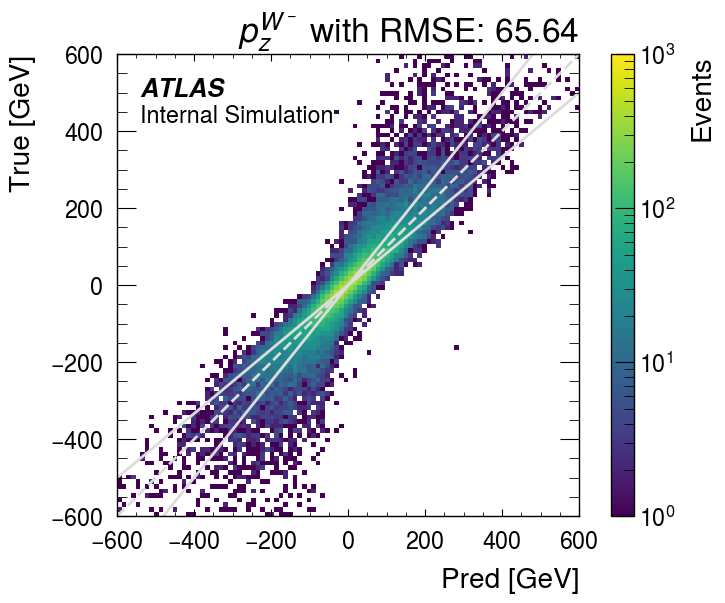

In [13]:
bins = np.linspace(-600, 600, 101)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True)

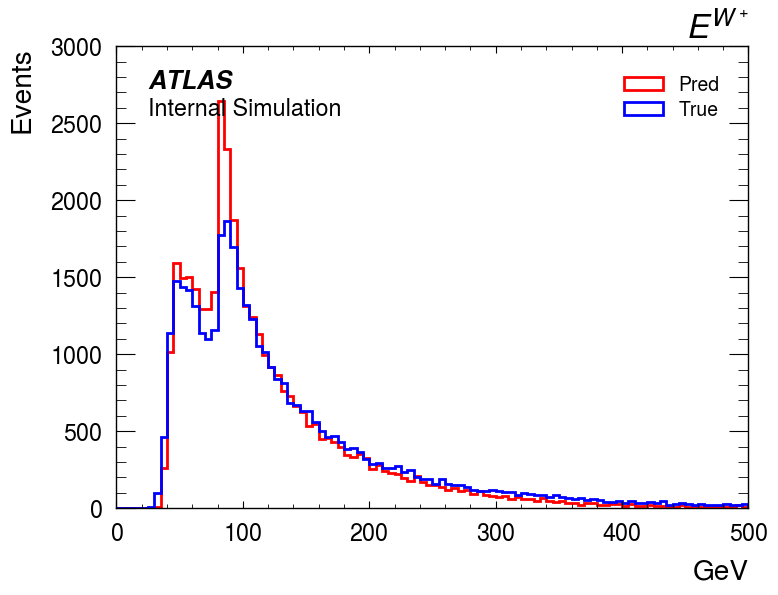

Rel err < 20%: 58.37 %


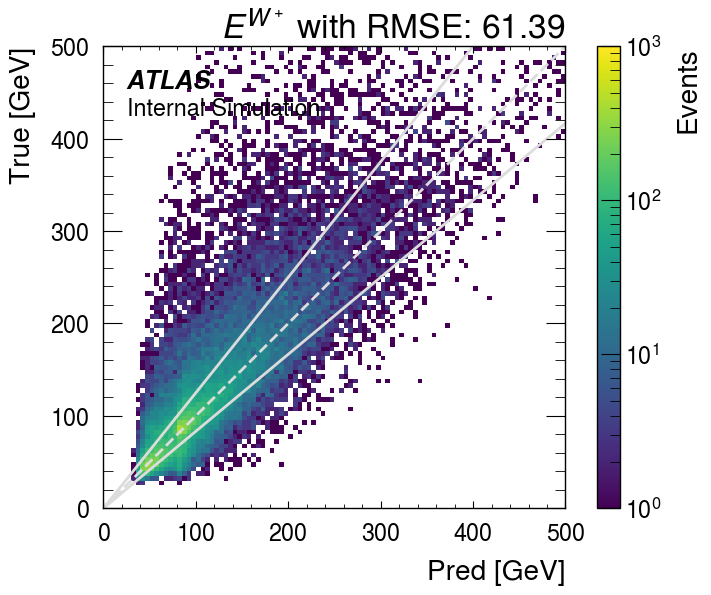

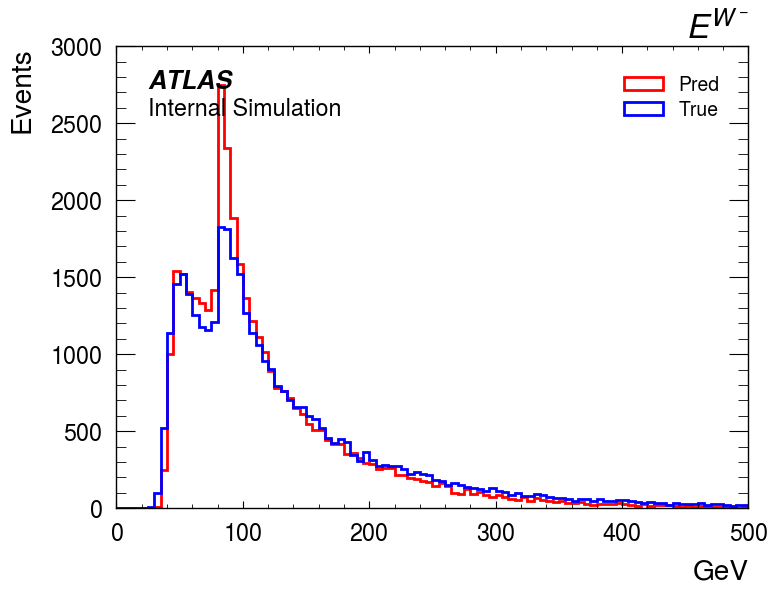

Rel err < 20%: 57.74 %


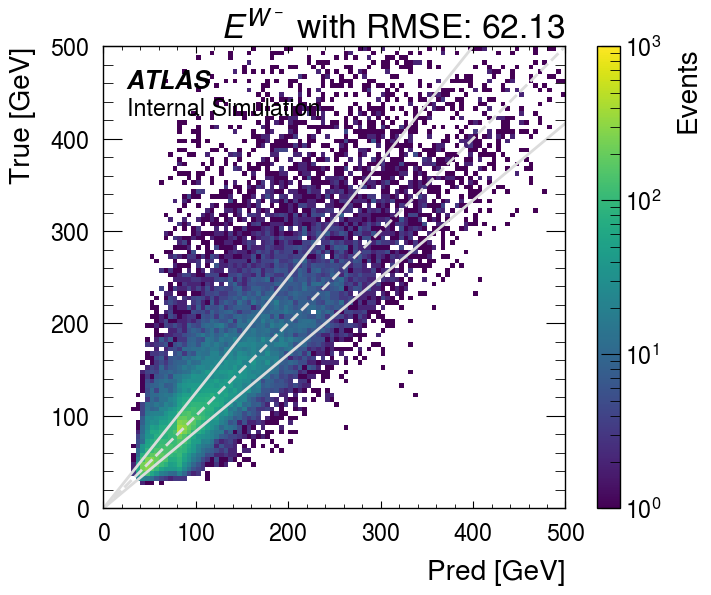

In [14]:
bins = np.linspace(0, 500, 101)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black")
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black")

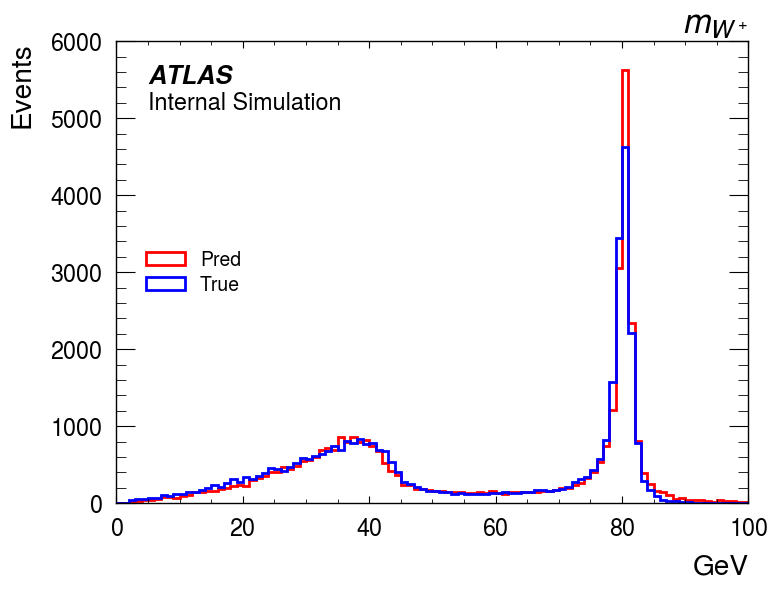

Rel err < 20%: 54.26 %


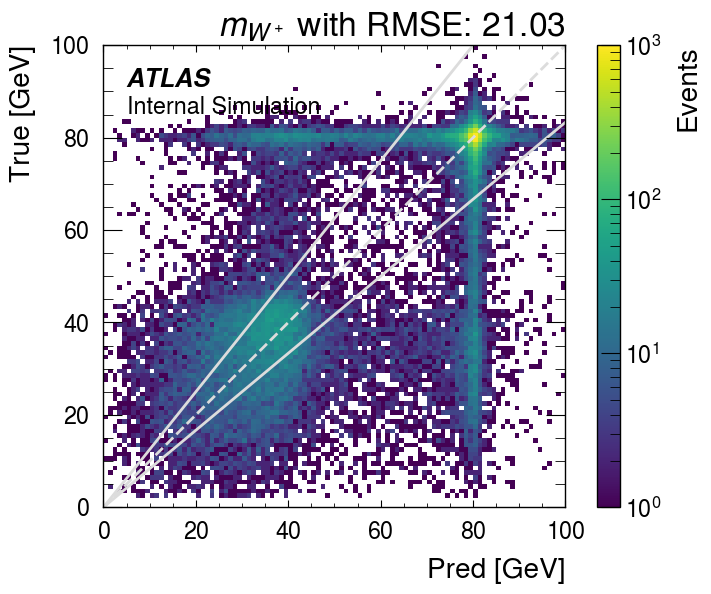

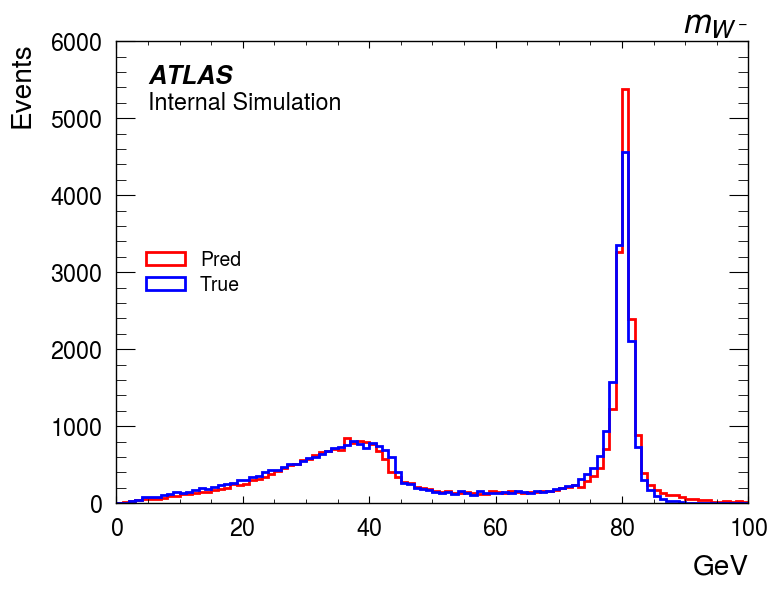

Rel err < 20%: 53.44 %


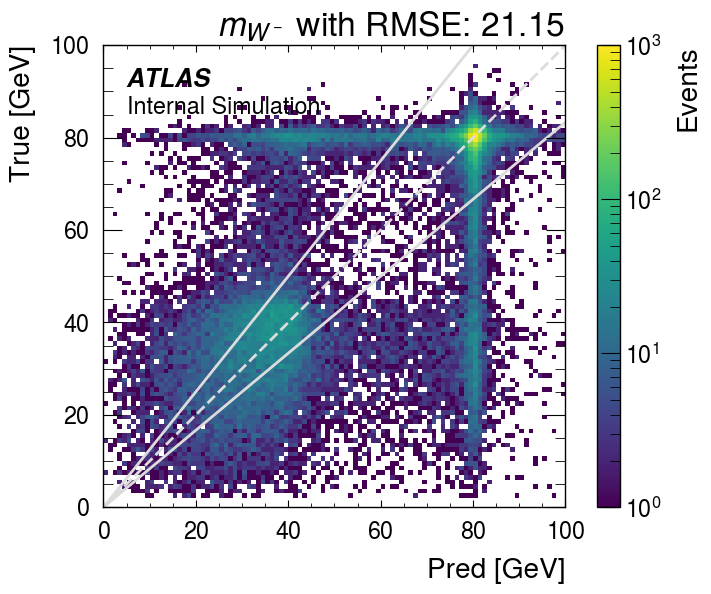

In [15]:
bins = np.linspace(0, 100, 101)
plot_1d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV")
plot_1d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV")

In [16]:
def plot_2d_res_hist(pred, truth, name_pos, name_neg, bins_edges=np.linspace(-200, 200, 101), log=False, unit="GeV", color="black", vmax=5e3, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    plt.xlabel(rf"$\Delta_\text{{res}}${name_pos} [{unit}]")
    plt.ylabel(rf"$\Delta_\text{{res}}${name_neg} [{unit}]")
    # plt.title(rf"{title}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=0, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

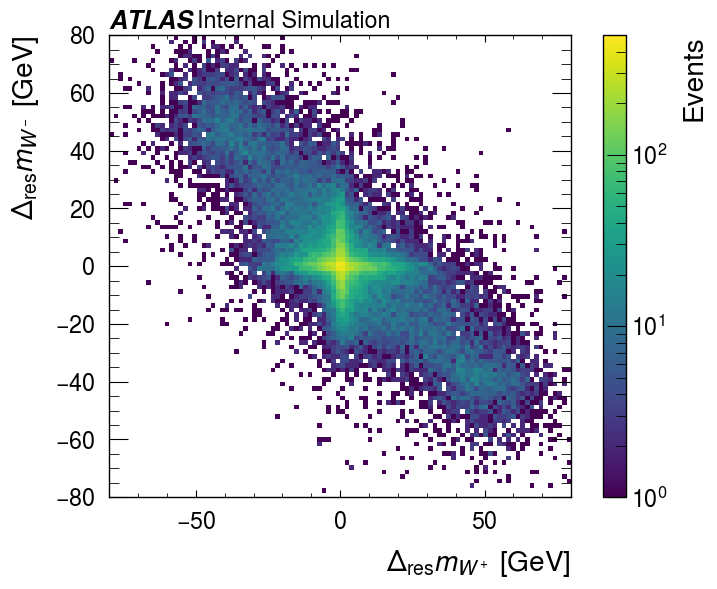

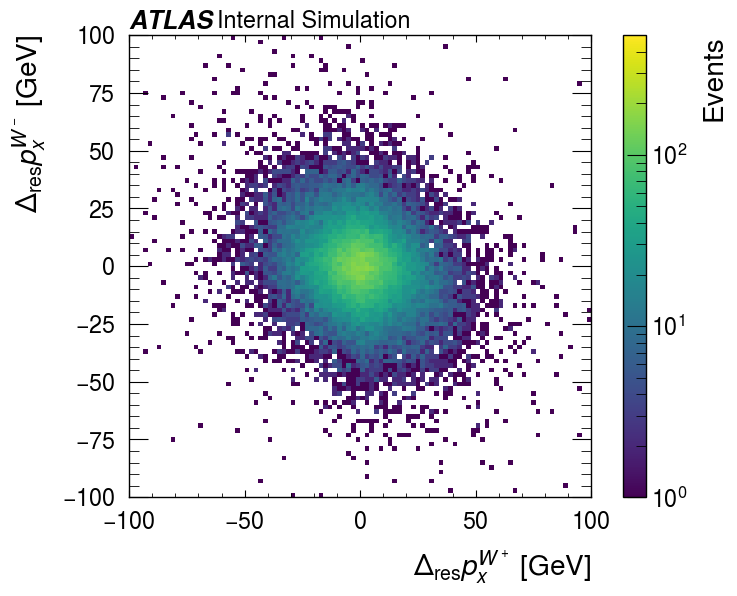

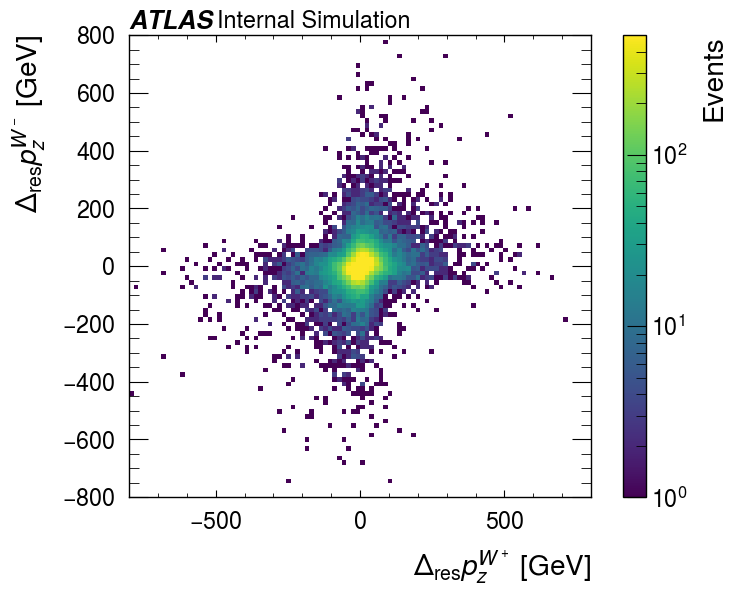

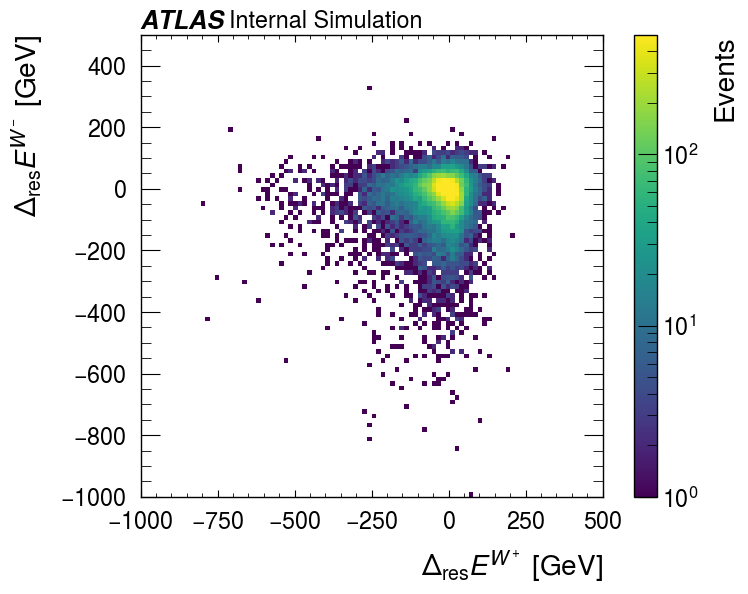

In [20]:
w0_mass_res = np.sqrt(pred_w0_mass_2) - np.sqrt(true_w0_mass_2)
w1_res = np.sqrt(pred_w1_mass_2) - np.sqrt(true_w1_mass_2)
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 101), log=True, unit="GeV", color="black", vmax=5e2)

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 101), log=True, unit="GeV", color="black", vmax=5e2)

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 101), log=True, unit="GeV", color="black", vmax=5e2)

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 101), log=True, unit="GeV", color="black", vmax=5e2)

In [21]:
from ohbboosting import Booster

true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=1)
true_l0_p4 = np.stack([true_lep0_px,true_lep0_py,true_lep0_pz,true_lep0_energy], axis=1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=1)
true_l1_p4 = np.stack([true_lep1_px,true_lep1_py,true_lep1_pz,true_lep1_energy], axis=1)

particles = np.concatenate(
	[
		true_w0_p4,
		true_l0_p4,
		true_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
true_l0_theta_phi, true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# true_xi_pos, true_xi_neg = booster.lep_xi_in_w_rest()
# true_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(37698, 16)


In [22]:
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1)

particles = np.concatenate(
	[
		pred_w0_p4,
		true_l0_p4, # we can measure lepton 4-momentum precisely
		pred_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi, pred_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
# pred_cglmp_bij = booster.cglmp_bij()

Make sure the input particles are ordered as [W+, l+, W-, l-]!
Booster setup completed.
(37698, 16)


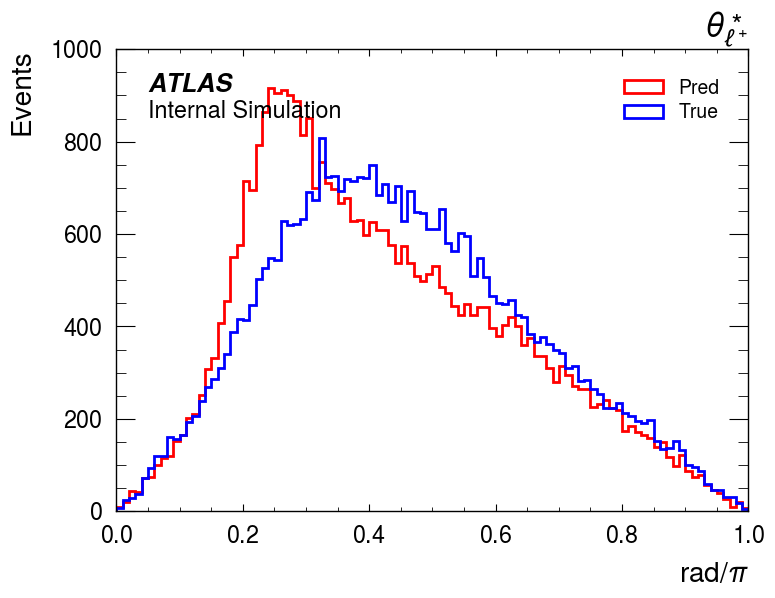

l+ theta RMSE: 0.22645961266538647
Rel err < 20%: 37.85 %


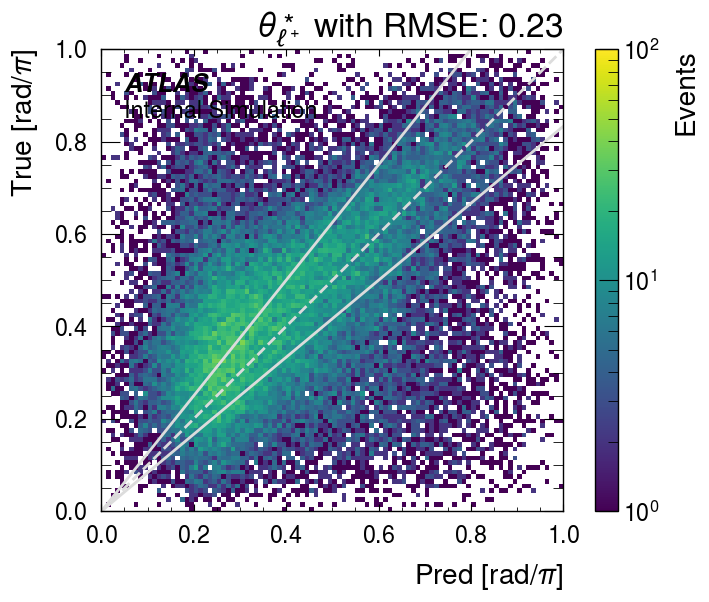

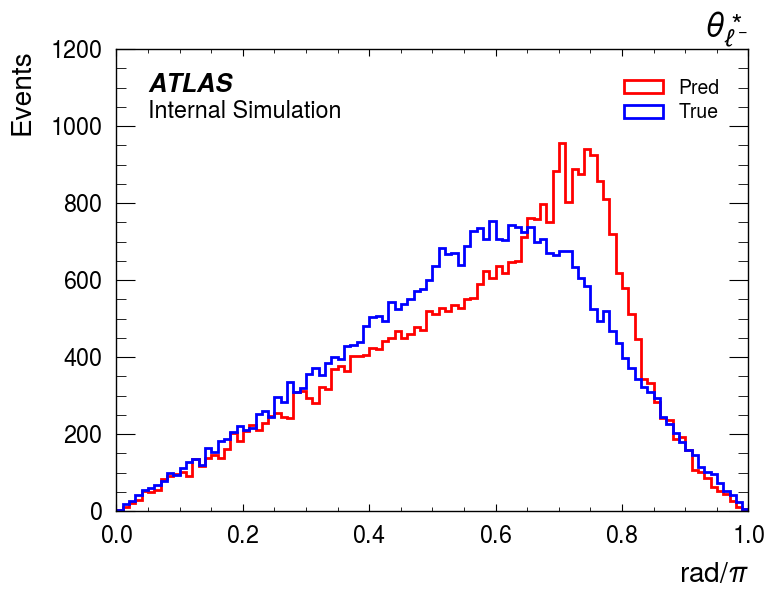

l_ theta RMSE: 0.22551646446218448
Rel err < 20%: 45.91 %


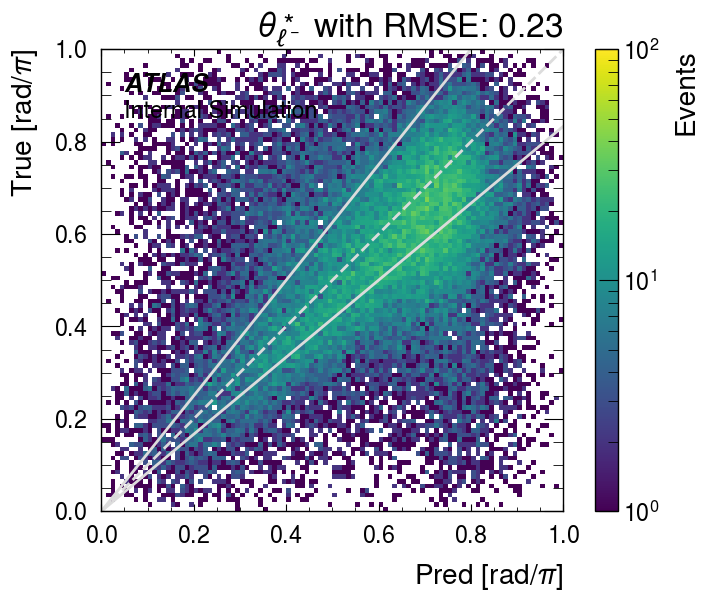

In [25]:
plot_1d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 101), unit="rad/$\pi$")
print("l+ theta RMSE:", rmse(pred_l0_theta_phi[0], true_l0_theta_phi[0]))
plot_2d_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 101), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 101), unit="rad/$\pi$")
print("l_ theta RMSE:", rmse(pred_l1_theta_phi[0], true_l1_theta_phi[0]))
plot_2d_hist(pred_l1_theta_phi[0], true_l1_theta_phi[0], r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 101), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

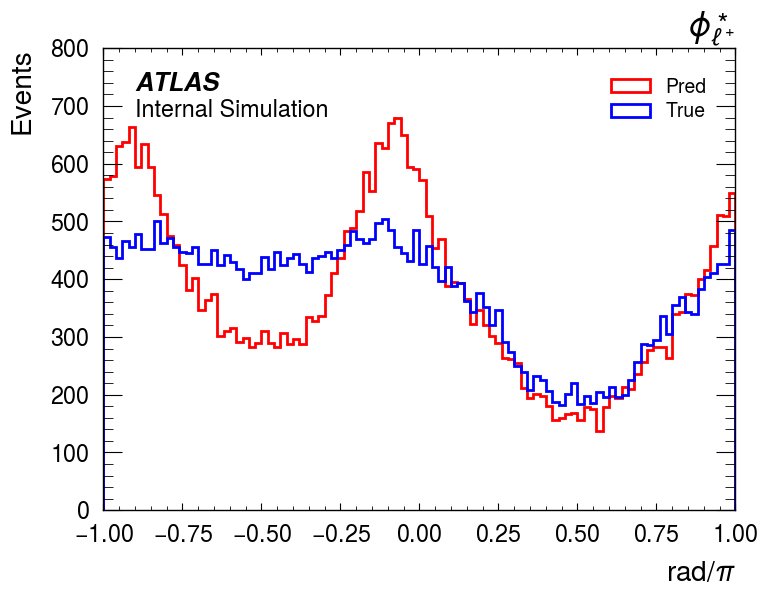

l+ phi RMSE: 0.7506877195646517
Rel err < 20%: 19.45 %


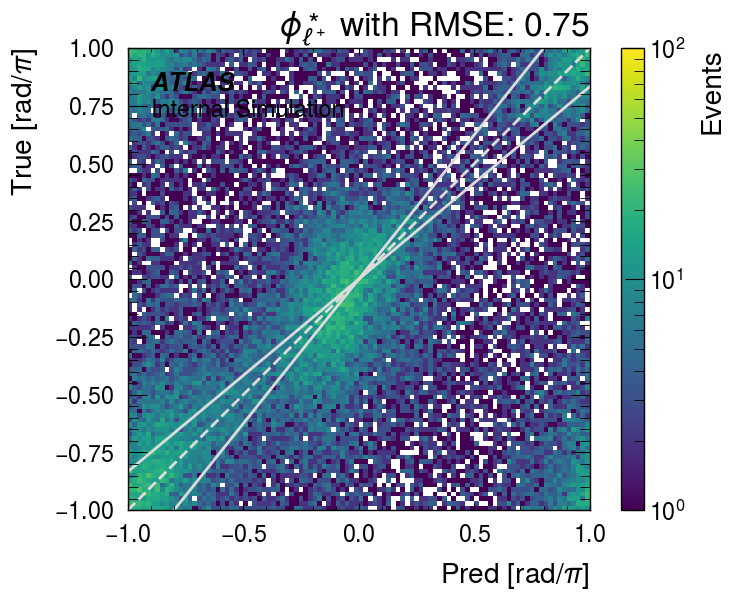

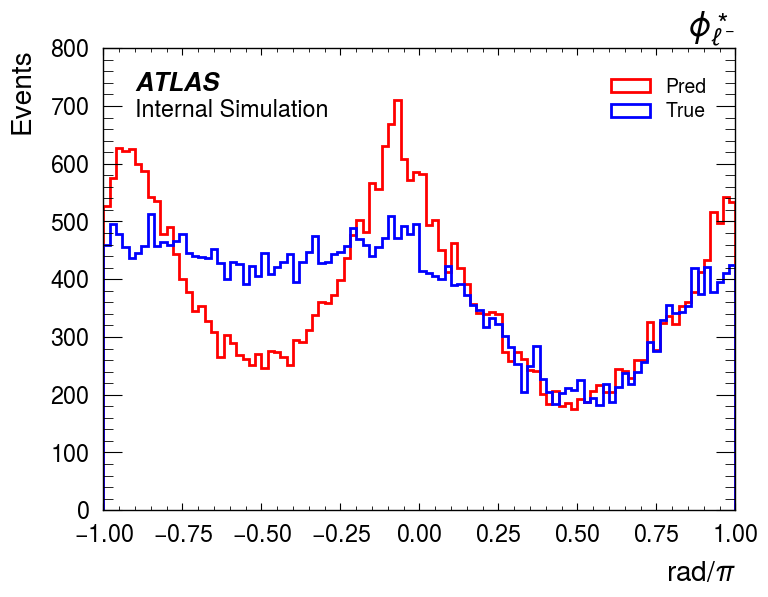

l- phi RMSE: 0.7417044695884832
Rel err < 20%: 19.91 %


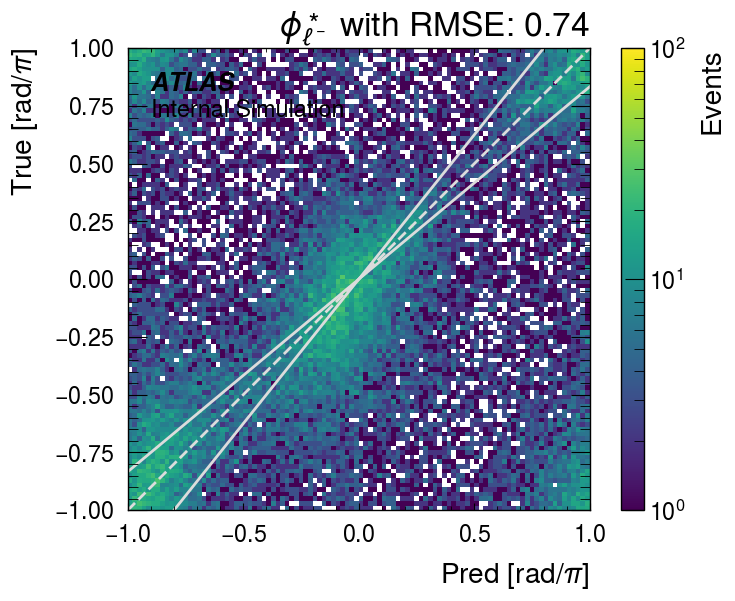

In [27]:
plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 101), unit="rad/$\pi$")
print("l+ phi RMSE:", rmse(pred_l0_theta_phi[1], true_l0_theta_phi[1]))
plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 101), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 101), unit="rad/$\pi$")
print("l- phi RMSE:", rmse(pred_l1_theta_phi[1], true_l1_theta_phi[1]))
plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 101), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

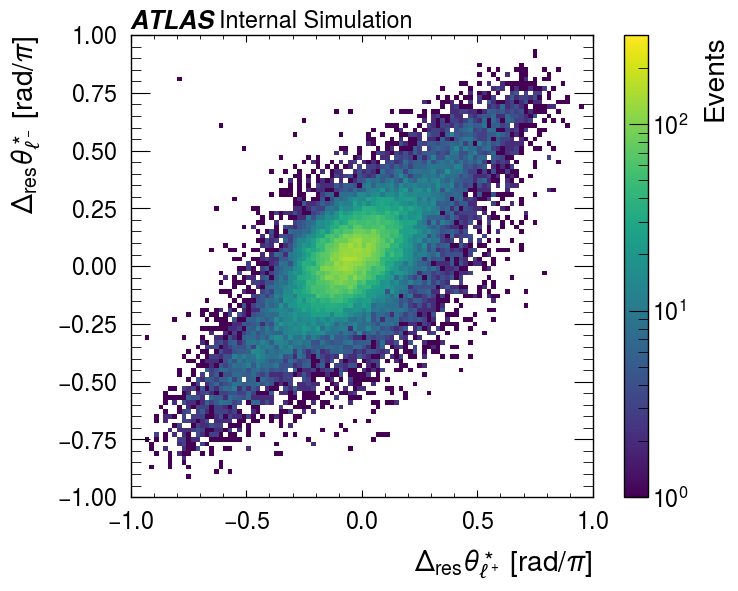

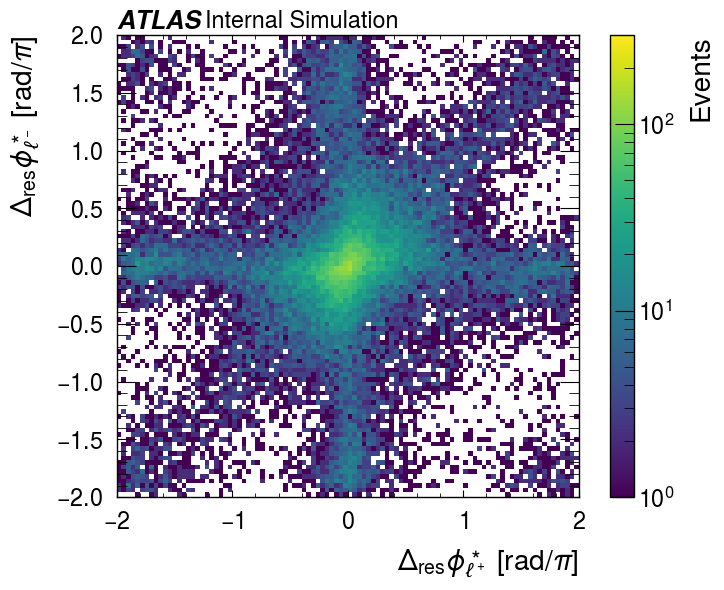

In [30]:
l0_theta_res = pred_l0_theta_phi[0] - true_l0_theta_phi[0]
l1_theta_res = pred_l1_theta_phi[0] - true_l1_theta_phi[0]
plot_2d_res_hist(l0_theta_res, l1_theta_res, name_pos=r"$\theta^\ast_{\ell^+}$", name_neg=r"$\theta^\ast_{\ell^-}$", bins_edges=np.linspace(-1, 1, 101), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

l0_phi_res = pred_l0_theta_phi[1] - true_l0_theta_phi[1]
l1_phi_res = pred_l1_theta_phi[1] - true_l1_theta_phi[1]
plot_2d_res_hist(l0_phi_res, l1_phi_res, name_pos=r"$\phi^\ast_{\ell^+}$", name_neg=r"$\phi^\ast_{\ell^-}$", bins_edges=np.linspace(-2, 2, 101), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

In [31]:
def dphi(phi1, phi2):
    phi_diff = phi1 * np.pi - phi2 * np.pi
    phi_diff = np.where(phi_diff < 0.0, -phi_diff, phi_diff)
    phi_diff = np.where(phi_diff > 2.0 * np.pi, phi_diff - 2.0 * np.pi, phi_diff)
    phi_diff = np.where(phi_diff >= np.pi, 2.0 * np.pi - phi_diff, phi_diff)
    return np.divide(phi_diff, np.pi)

def dtheta(theta1, theta2):
	theta_diff = theta1 * np.pi - theta2 * np.pi
	theta_diff = np.where(theta_diff < 0.0, -theta_diff, theta_diff)
	theta_diff = np.where(theta_diff > np.pi, theta_diff - np.pi, theta_diff)
	return np.divide(theta_diff, np.pi)

In [32]:
def plot_1d_true_pred_diff(diff, name, bins_edges=np.linspace(-1, 1, 51), unit="rad/$\pi$", color="black", savepath=None):
	plt.hist(diff, bins=bins_edges, linewidth=2, color="green", histtype="step", label=name)
	plt.legend()
	plt.xlabel(f"{name} [{unit}]", loc="right")
	plt.ylabel("Events", loc="top")
	# plt.title(name, loc="right")
	
	txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
	txt[0].set_color(color)
	txt[1].set_color(color)
	plt.tick_params(axis="both", which="major", pad=10)
	if savepath is not None:
		plt.savefig(savepath, bbox_inches="tight")
	plt.show()

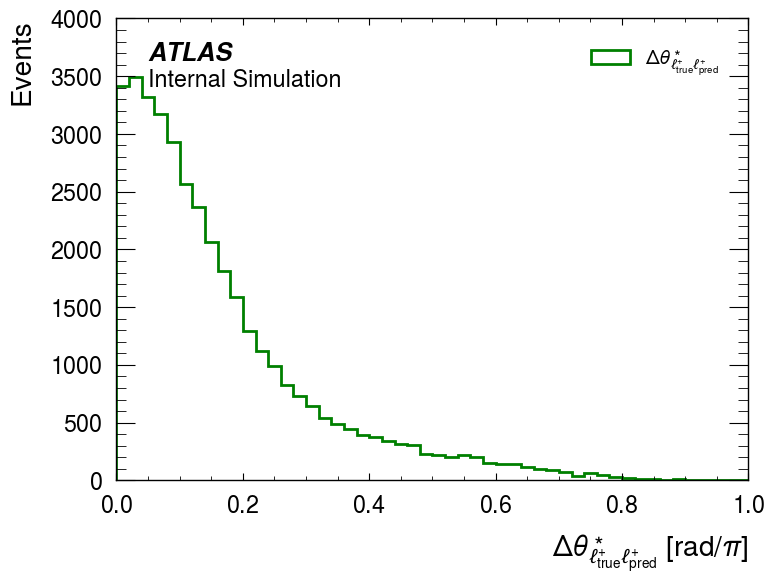

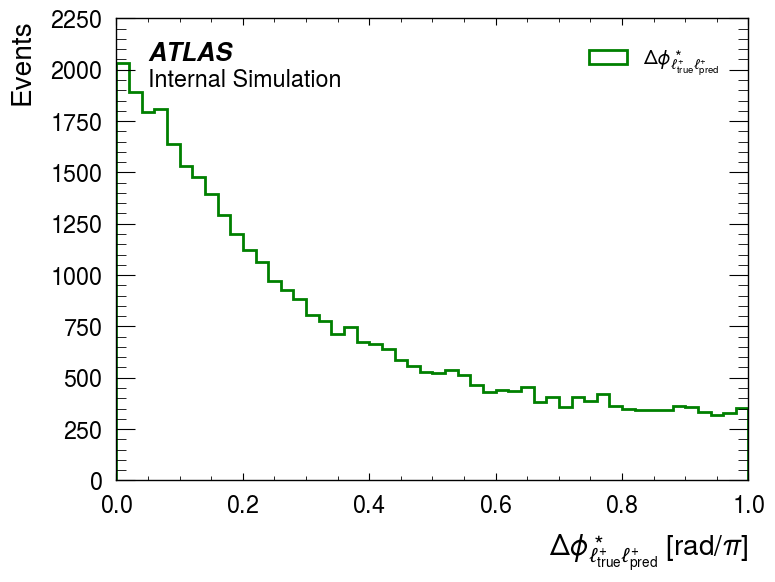

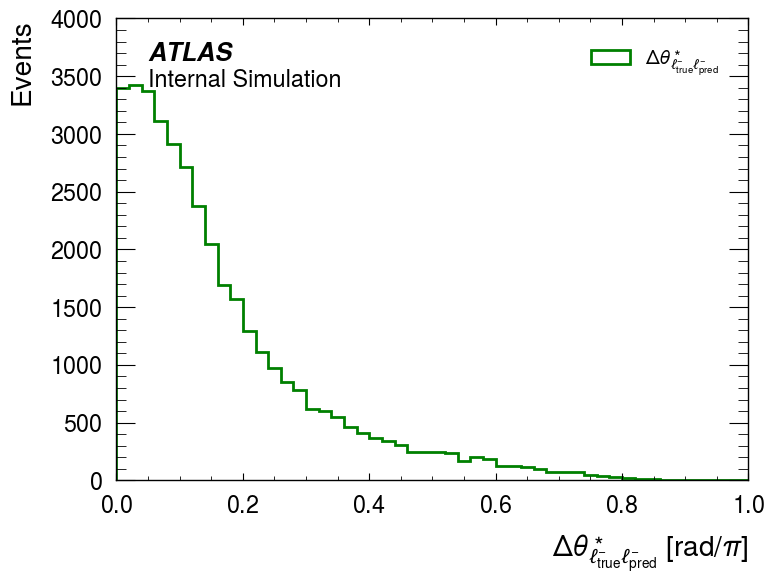

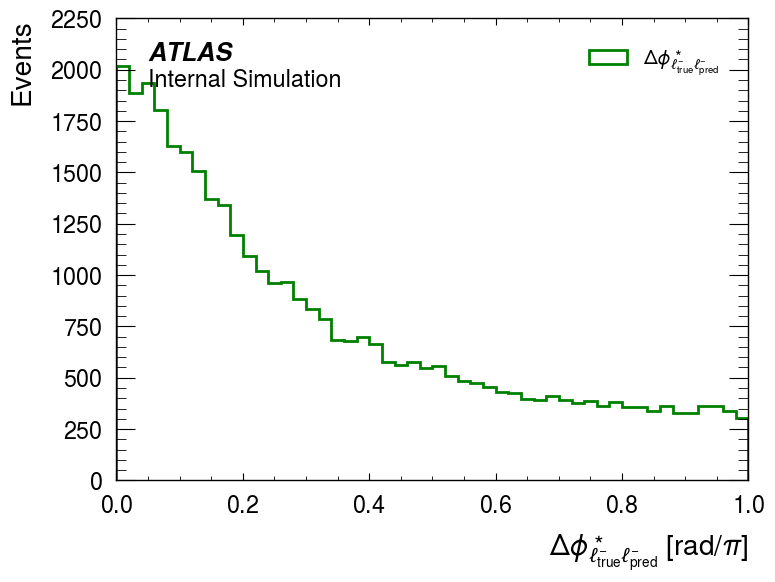

In [35]:
dtheta_pos = dtheta(pred_l0_theta_phi[0], true_l0_theta_phi[0])
dphi_pos = dphi(pred_l0_theta_phi[1], true_l0_theta_phi[1])
dtheta_neg = dtheta(pred_l1_theta_phi[0], true_l1_theta_phi[0])
dphi_neg = dphi(pred_l1_theta_phi[1], true_l1_theta_phi[1])

plot_1d_true_pred_diff(dtheta_pos, r"$\Delta \theta_{\ell^{+}_\text{true}\ell^{+}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dphi_pos, r"$\Delta \phi_{\ell^{+}_\text{true}\ell^{+}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dtheta_neg, r"$\Delta \theta_{\ell^{-}_\text{true}\ell^{-}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_1d_true_pred_diff(dphi_neg, r"$\Delta \phi_{\ell^{-}_\text{true}\ell^{-}_\text{pred}}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$")

In [36]:
# plot_1d_hist(dtheta(pred_l0_theta_phi[0], pred_l1_theta_phi[0]), dtheta(true_l0_theta_phi[0], true_l1_theta_phi[0]), r"$\Delta \theta_{\ell\ell}^\ast$", np.linspace(0, 0.8, 51), unit="rad/$\pi$", savepath="./figures/dilep/delta_theta.pdf")
# plot_2d_hist(dtheta(pred_l0_theta_phi[0], pred_l1_theta_phi[0]), dtheta(true_l0_theta_phi[0], true_l1_theta_phi[0]), r"$\Delta \theta_{\ell\ell}^\ast$", np.linspace(0, 0.8, 51), log=True, unit="rad/$\pi$", vmax=2e3, savepath="./figures/dilep/delta_theta_2d.pdf")
# plot_1d_hist(dphi(pred_l0_theta_phi[1], pred_l1_theta_phi[1]), dphi(true_l0_theta_phi[1], true_l1_theta_phi[1]), r"$\Delta \phi_{\ell\ell}^\ast$", np.linspace(0, 1, 51), unit="rad/$\pi$", savepath="./figures/dilep/delta_phi.pdf")
# plot_2d_hist(dphi(pred_l0_theta_phi[1], pred_l1_theta_phi[1]), dphi(true_l0_theta_phi[1], true_l1_theta_phi[1]), r"$\Delta \phi_{\ell\ell}^\ast$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=2e3, savepath="./figures/dilep/delta_phi_2d.pdf")

In [37]:
def plot_1d_swap_hist(pred, truth, pred_swap, true_swap, name, bins_edges=np.linspace(-200, 200, 101), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.hist(pred_swap, bins=bins_edges, linewidth=2, color="tab:orange", histtype="step", label="Pred (tagged)")
    plt.hist(true_swap, bins=bins_edges, linewidth=2, color="tab:blue", histtype="step", label="True (tagged)")
    plt.semilogy()
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")

    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

def plot_2d_swap_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 101), log=False, unit="GeV", color="black", vmax=5e3, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

In [38]:
# off-shell := 0 < mW < 50 GeV
# on-shell := 70 GeV < mW < 90 GeV

true_w0_mass = np.sqrt(true_w0_mass_2)
true_w1_mass = np.sqrt(true_w1_mass_2)
pred_w0_mass = np.sqrt(pred_w0_mass_2)
pred_w1_mass = np.sqrt(pred_w1_mass_2)

true_off_w0 = (10 < true_w0_mass) & (true_w0_mass < 50)
true_on_w0 =(70 < true_w0_mass) & (true_w0_mass < 90)
pred_off_w0 = (10 < pred_w0_mass) & (pred_w0_mass < 50)
pred_on_w0 = (70 < pred_w0_mass) & (pred_w0_mass < 90)
pred_correct_w0 = true_off_w0 * pred_off_w0 + true_on_w0 * pred_on_w0
pred_swap_w0 = true_off_w0 * pred_on_w0 + true_on_w0 * pred_off_w0

true_off_w1 = (10 < true_w1_mass) & (true_w1_mass < 50)
true_on_w1 =(70 < true_w1_mass) & (true_w1_mass < 90)
pred_off_w1 = (10 < pred_w1_mass) & (pred_w1_mass < 50)
pred_on_w1 = (70 < pred_w1_mass) & (pred_w1_mass < 90)
pred_correct_w1 = true_off_w1 * pred_off_w1 + true_on_w1 * pred_on_w1
pred_swap_w1 = true_off_w1 * pred_on_w1 + true_on_w1 * pred_off_w1

# # consider both W bosons
# pred_correct = pred_correct_w0 & pred_correct_w1
# pred_swap = pred_swap_w0 | pred_swap_w1

# consider W+ boson only
pred_correct = pred_correct_w0
pred_swap = pred_swap_w0

In [39]:
# plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_swap], true_w0_mass[pred_swap], "$m_{W^+}$ swapped", np.linspace(0, 100, 101))
# plot_2d_swap_hist(pred_w0_mass[pred_swap], true_w0_mass[pred_swap], "$m_{W^+}$ swapped", np.linspace(0, 100, 101), log=True)
# plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ swapped", np.linspace(0, 100, 101))
# plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(0, 100, 101), log=True)

# plot_1d_swap_hist(pred_w0_px, true_w0_px, pred_w0_px[pred_swap], true_w0_px[pred_swap], "$p^{W^+}_x$ swapped", np.linspace(-200, 200, 101))
# plot_2d_swap_hist(pred_w0_px[pred_swap], true_w0_px[pred_swap], "$p^{W^+}_x$ swapped", np.linspace(-200, 200, 101), log=True)
# plot_1d_swap_hist(pred_w0_pz, true_w0_pz, pred_w0_pz[pred_swap], true_w0_pz[pred_swap], "$p^{W^+}_z$ swapped", np.linspace(-600, 600, 101))
# plot_2d_swap_hist(pred_w0_pz[pred_swap], true_w0_pz[pred_swap], "$p^{W^+}_z$ swapped", np.linspace(-600, 600, 101), log=True)
# plot_1d_swap_hist(pred_w0_energy, true_w0_energy, pred_w0_energy[pred_swap], true_w0_energy[pred_swap], "$E^{W^+}$ swapped", np.linspace(0, 300, 101))
# plot_2d_swap_hist(pred_w0_energy[pred_swap], true_w0_energy[pred_swap], "$E^{W^+}$ swapped", np.linspace(0, 300, 101), log=True, color="black",)

# plot_1d_swap_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], pred_l0_theta_phi[0][pred_swap], true_l0_theta_phi[0][pred_swap], r"$\theta^\ast_{\ell^+}$ swapped", np.linspace(0, 1, 101), unit="rad/$\pi$")
# plot_2d_swap_hist(pred_l0_theta_phi[0][pred_swap], true_l0_theta_phi[0][pred_swap], r"$\theta^\ast_{\ell^+}$ swapped", np.linspace(0, 1, 101), vmax=1e3, log=True, unit="rad/$\pi$", color="black",)
# plot_1d_swap_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], pred_l0_theta_phi[1][pred_swap], true_l0_theta_phi[1][pred_swap], r"$\phi^\ast_{\ell^+}$ swapped", np.linspace(-1, 1, 101), unit="rad/$\pi$")
# plot_2d_swap_hist(pred_l0_theta_phi[1][pred_swap], true_l0_theta_phi[1][pred_swap], r"$\phi^\ast_{\ell^+}$ swapped", np.linspace(-1, 1, 101), vmax=1e3, log=True, unit="rad/$\pi$", color="black",)

In [40]:
# plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(-10, 120, 101))
# plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(-10, 120, 101), log=True)
# plot_1d_swap_hist(pred_w0_mass, true_w0_mass, pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(-10, 120, 101))
# plot_2d_swap_hist(pred_w0_mass[pred_correct], true_w0_mass[pred_correct], "$m_{W^+}$ correct", np.linspace(-10, 120, 101), log=True)

# plot_1d_swap_hist(pred_w0_px, true_w0_px, pred_w0_px[pred_correct], true_w0_px[pred_correct], "$p^{W^+}_x$ correct", np.linspace(-200, 200, 101))
# plot_2d_swap_hist(pred_w0_px[pred_correct], true_w0_px[pred_correct], "$p^{W^+}_x$ correct", np.linspace(-200, 200, 101), log=True)
# plot_1d_swap_hist(pred_w0_pz, true_w0_pz, pred_w0_pz[pred_correct], true_w0_pz[pred_correct], "$p^{W^+}_z$ correct", np.linspace(-600, 600, 101))
# plot_2d_swap_hist(pred_w0_pz[pred_correct], true_w0_pz[pred_correct], "$p^{W^+}_z$ correct", np.linspace(-600, 600, 101), log=True)
# plot_1d_swap_hist(pred_w0_energy, true_w0_energy, pred_w0_energy[pred_correct], true_w0_energy[pred_correct], "$E^{W^+}$ correct", np.linspace(0, 300, 101))
# plot_2d_swap_hist(pred_w0_energy[pred_correct], true_w0_energy[pred_correct], "$E^{W^+}$ correct", np.linspace(0, 300, 101), log=True, color="black",)

# plot_1d_swap_hist(pred_l0_theta_phi[0], true_l0_theta_phi[0], pred_l0_theta_phi[0][pred_correct], true_l0_theta_phi[0][pred_correct], r"$\theta^\ast_{\ell^+}$ correct", np.linspace(0, 1, 101), unit="rad/$\pi$")
# plot_2d_swap_hist(pred_l0_theta_phi[0][pred_correct], true_l0_theta_phi[0][pred_correct], r"$\theta^\ast_{\ell^+}$ correct", np.linspace(0, 1, 101), vmax=1e3, log=True, unit="rad/$\pi$", color="black",)
# plot_1d_swap_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], pred_l0_theta_phi[1][pred_correct], true_l0_theta_phi[1][pred_correct], r"$\phi^\ast_{\ell^+}$ correct", np.linspace(-1, 1, 101), unit="rad/$\pi$")
# plot_2d_swap_hist(pred_l0_theta_phi[1][pred_correct], true_l0_theta_phi[1][pred_correct], r"$\phi^\ast_{\ell^+}$ correct", np.linspace(-1, 1, 101), vmax=1e3, log=True, unit="rad/$\pi$", color="black",)

Found log directories: ['./hww_pcres_regressor/logs/version_0']


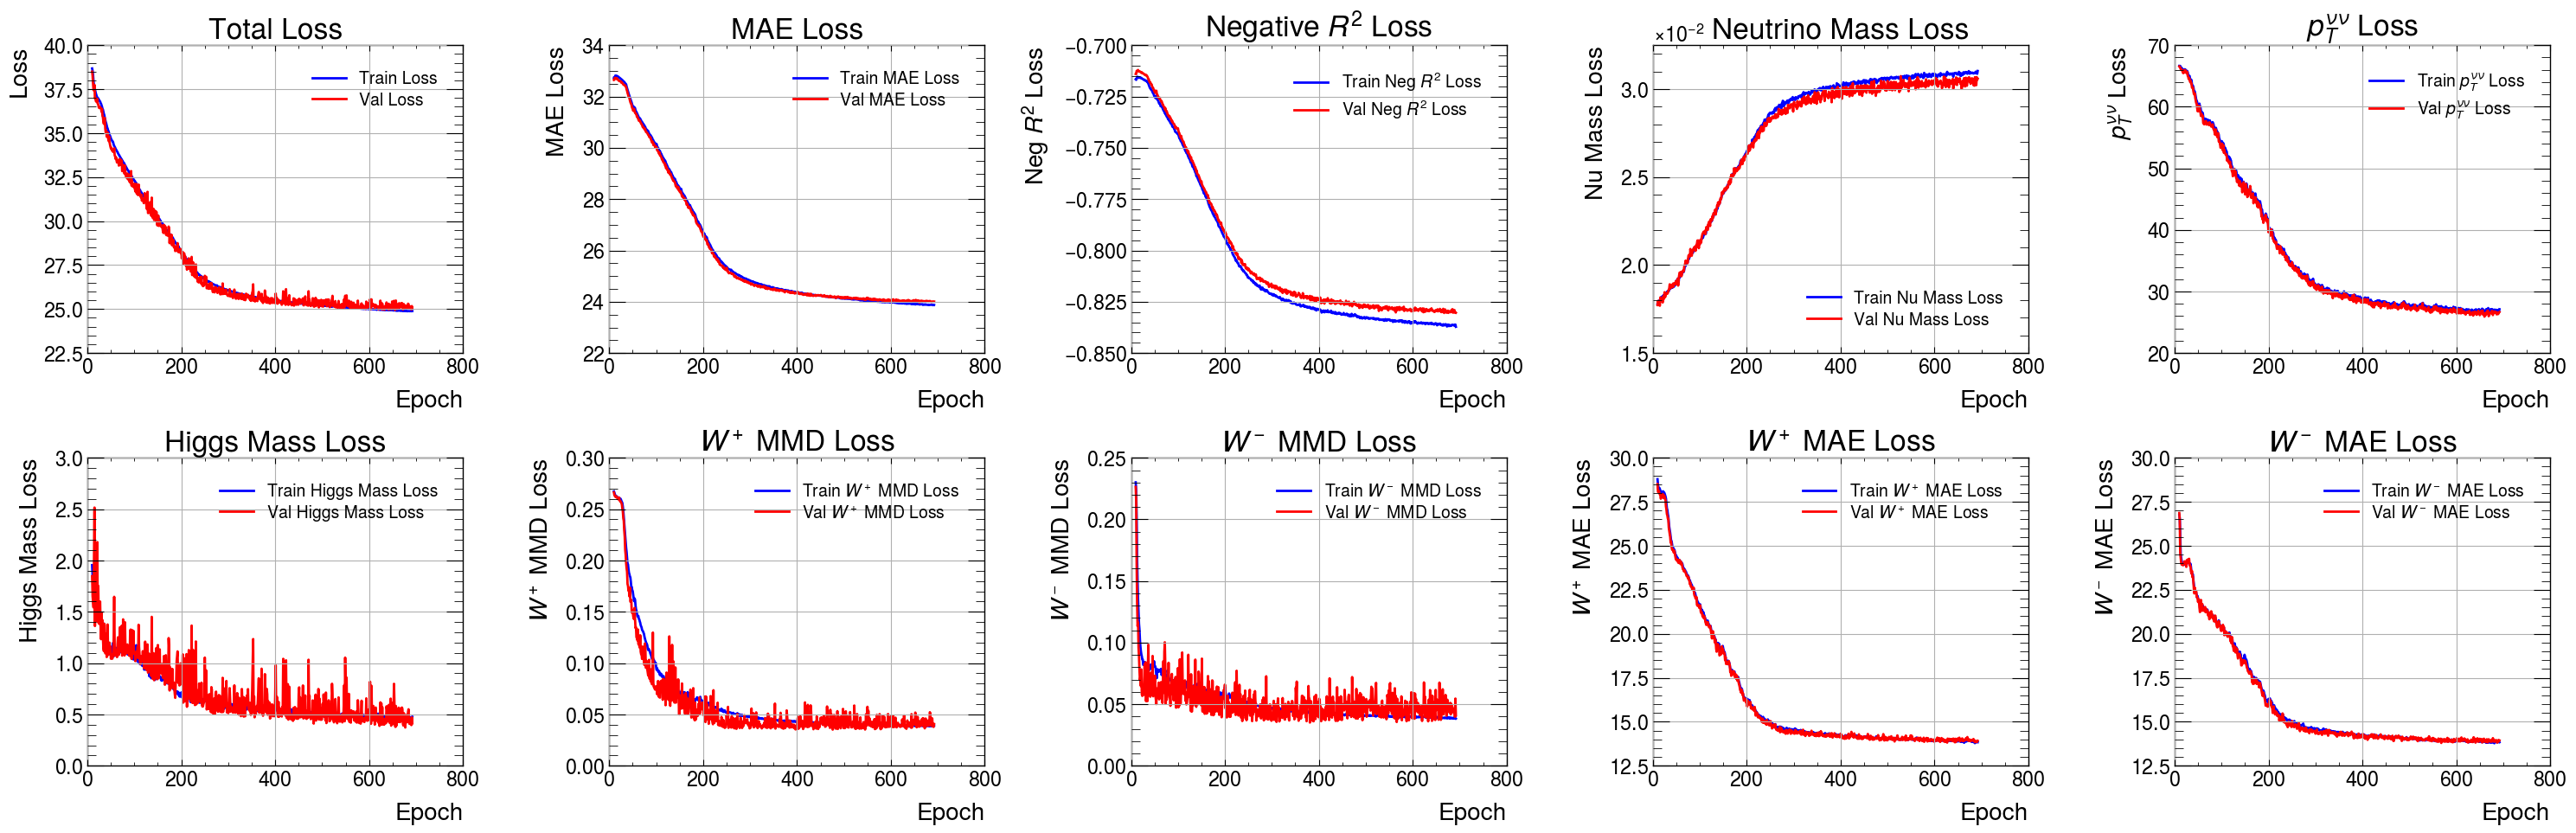

Final Training Losses (Epoch 692):
  Total Loss: 24.889395
  MAE Loss: 23.876822
  Negative $R^2$ Loss: -0.837198
  Neutrino Mass Loss: 0.031033
  $p^{\nu\nu}_T$ Loss: 27.119020
  Higgs Mass Loss: 0.477525
  $W^+$ MMD Loss: 0.039092
  $W^-$ MMD Loss: 0.038288
  $W^+$ MAE Loss: 13.838840
  $W^-$ MAE Loss: 13.836054
Final Validation Losses:
  Total Loss: 25.030266
  MAE Loss: 24.008772
  Negative $R^2$ Loss: -0.830339
  Neutrino Mass Loss: 0.030594
  $p^{\nu\nu}_T$ Loss: 26.669317
  Higgs Mass Loss: 0.412554
  $W^+$ MMD Loss: 0.040647
  $W^-$ MMD Loss: 0.040875
  $W^+$ MAE Loss: 13.917676
  $W^-$ MAE Loss: 13.941534


In [41]:
log_dirs = glob.glob("./hww_pcres_regressor/logs/*")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(2, 5, figsize=(30, 10))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("mae_loss", "val_mae_loss", "MAE Loss", "MAE Loss"),
                ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W^+$ MMD Loss", "$W^+$ MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W^-$ MMD Loss", "$W^-$ MMD Loss"),
                ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W^+$ MAE Loss", "$W^+$ MAE Loss"),
                ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W^-$ MAE Loss", "$W^-$ MAE Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[10:]
            epochs_val = df_clean_val["epoch"].iloc[10:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[10:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[10:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                # apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"Final Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("Final Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")

In [42]:
# import shap
# import matplotlib as mpl

# mpl.rcParams.update(mpl.rcParamsDefault)

# # Use GradientExplainer with separate background and test samples
# background_sample = torch.tensor(train_features[0:256]).float().to(device)
# samples_to_explain = torch.tensor(train_features[512:512+1024]).float().to(device)
# explainer = shap.GradientExplainer(model, background_sample)
# shap_values = explainer.shap_values(samples_to_explain, nsamples=200)

# for i in range(shap_values.shape[-1]):
# 	fig = plt.figure(figsize=(10, 8))
# 	shap.summary_plot(
# 		shap_values[:, :, i],
# 		samples_to_explain.cpu().numpy(),
# 		# No feature_names - will use feature indices 0-71
# 		plot_type="dot",
# 		max_display=10,
# 		show=False,
# 	)
# 	plt.title(f"SHAP Summary Plot for Output {i}", fontsize=16)
# 	plt.tight_layout()
# 	plt.show()

In [43]:
# Set mh = 125.0 GeV and solve pz of (nu1) W1 (detail please see ./mh_constraint.md)
# Pzv1 and Ev1 are unknowns

mh = 125.0

def A(Ew0, El1):    
    return Ew0 + El1

def B(
        Pxw0, Pxw1, 
        Pyw0, Pyw1,
        Pzl1, Pzw0
    ):
    Pxh = Pxw0 + Pxw1
    Pyh = Pyw0 + Pyw1
    
    return Pxh + Pyh + Pzw0 + Pzl1

def Ptv1(Pxw1, Pxl1, Pyw1, Pyl1): # can be regressed from NN
    Pxv1 = Pxw1 - Pxl1
    Pyv1 = Pyw1 - Pyl1
    return np.sqrt(Pxv1**2 + Pyv1**2)

def C(A, B, Ptv1):
    return 0.25 * (mh**2 + (B**2 - A**2) - Ptv1**2)**2 -A**2 * Ptv1**2



def trunk(A, B, C, Ptv1):
    term = (A**2 * B**2 * (C + A**2 * Ptv1**2) * (C + B**2 * Ptv1**2))
    return B**2 * C + 2 * np.sqrt(term) + A**2 * (C + 2 * B**2 * Ptv1**2)

def Pzv1_sol1(A, B, C, Ptv1):
    term = trunk(A, B, C, Ptv1)
    return - np.sqrt(C**2 / term)

def Pzv1_sol2(A, B, C, Ptv1):
    term = trunk(A, B, C, Ptv1)
    return np.sqrt(C**2 / term)

def Pzv1_sol3(A, B, C, Ptv1):
    term1 = trunk(A, B, C, Ptv1)
    term2 = (A**2 - B**2)**2
    return -np.sqrt(term1 / term2)

def Pzv1_sol4(A, B, C, Ptv1):
    term1 = trunk(A, B, C, Ptv1)
    term2 = (A**2 - B**2)**2
    return np.sqrt(term1 / term2)

In [44]:
A_values = A(pred_w1_energy, true_lep0_energy)
B_values = B(
	pred_w0_px, pred_w1_px,
	pred_w0_py, pred_w1_py,
	true_lep1_pz, pred_w0_pz
)
Ptv1_values = Ptv1(pred_w1_px, true_lep1_px, pred_w1_py, true_lep1_py)
C_values = C(A_values, B_values, Ptv1_values)


Pzv1_sol1_values = Pzv1_sol1(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol2_values = Pzv1_sol2(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol3_values = Pzv1_sol3(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol4_values = Pzv1_sol4(A_values, B_values, C_values, Ptv1_values)

/tmp/ipykernel_144296/3050176126.py:31: RuntimeWarning: invalid value encountered in sqrt
  return B**2 * C + 2 * np.sqrt(term) + A**2 * (C + 2 * B**2 * Ptv1**2)


Number of events with no valid Pzv1 solution: 11585 out of 37698
Selected Pzv1 shape: (37698,)


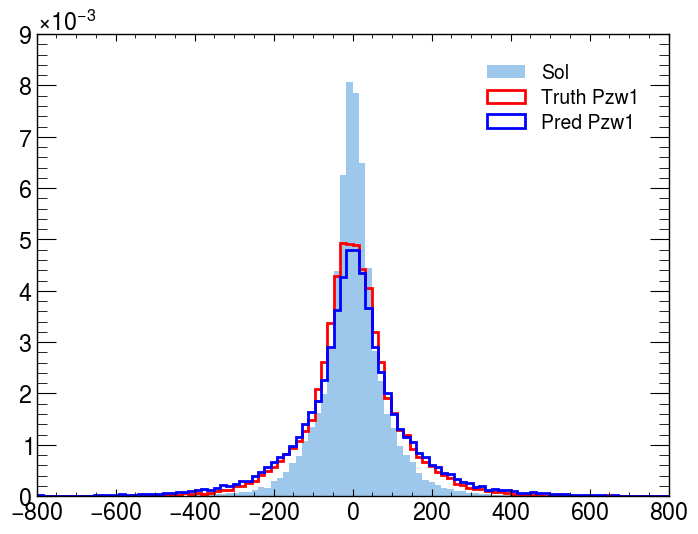

In [45]:
solutions = np.stack(
    [Pzv1_sol1_values, Pzv1_sol2_values, Pzv1_sol3_values, Pzv1_sol4_values],
    axis=1,
)

# rng = np.random.default_rng(42)
selected_pzv1 = np.zeros(Pzv1_sol1_values.shape[0])
zeros_counts = 0
for i, row in enumerate(solutions):
    valid = row[np.isfinite(row)]
    if len(valid) > 0:
        # selected_pzv1[i] = rng.choice(valid)
        selected_pzv1[i] = valid.mean()
    if len(valid) == 0:
        zeros_counts += 1

print(f"Number of events with no valid Pzv1 solution: {zeros_counts} out of {solutions.shape[0]}")
print("Selected Pzv1 shape:", selected_pzv1.shape)

bins_edges = np.linspace(-800, 800, 101)
plt.hist(selected_pzv1+true_lep1_pz, bins=bins_edges, alpha=0.5, label="Sol", density=True)
plt.hist(pred_w1_pz, bins=bins_edges, histtype="step", linewidth=2, label="Truth Pzw1", density=True, color="red")
plt.hist(true_w1_pz, bins=bins_edges, histtype="step", linewidth=2, label="Pred Pzw1", density=True, color="blue")
plt.legend()
plt.show()

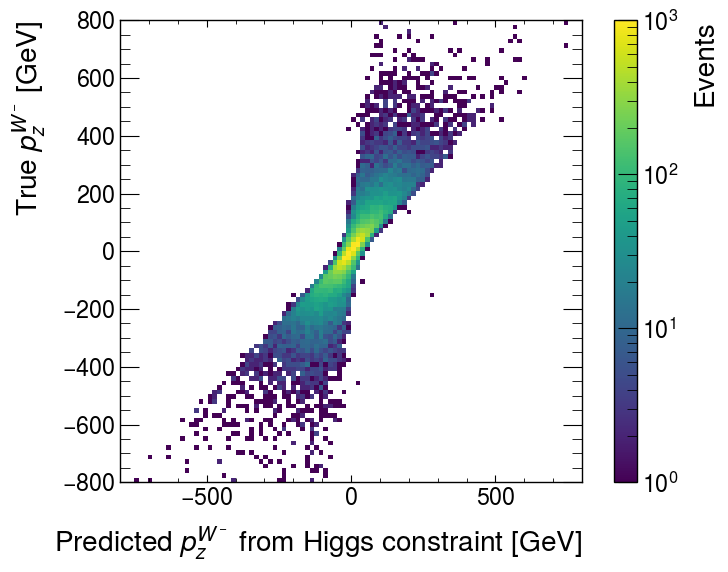

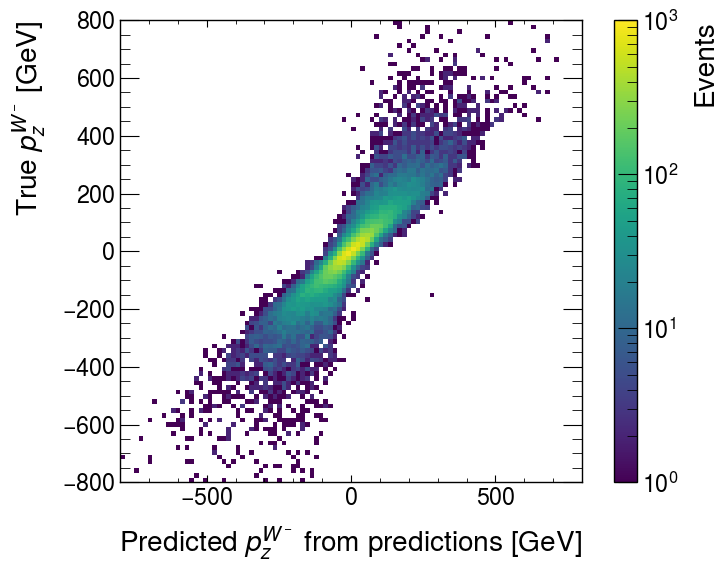

In [46]:
plt.hist2d(selected_pzv1+true_lep1_pz, true_w1_pz, bins=[bins_edges, bins_edges], cmap="viridis", norm=LogNorm(vmin=1, vmax=1e3))
plt.xlabel("Predicted $p_z^{W^-}$ from Higgs constraint [GeV]")
plt.ylabel("True $p_z^{W^-}$ [GeV]")
plt.colorbar(label="Events")
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.show()

plt.hist2d(pred_w1_pz, true_w1_pz, bins=[bins_edges, bins_edges], cmap="viridis", norm=LogNorm(vmin=1, vmax=1e3))
plt.xlabel("Predicted $p_z^{W^-}$ from predictions [GeV]")
plt.ylabel("True $p_z^{W^-}$ [GeV]")
plt.colorbar(label="Events")
plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
plt.show()